## <span style="color:green">Solutions</span>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# 1. Convert the following dictionary into a Pandas Series
# and display on overview of basic statistics
# (count, mean, std, min,... see DataFrame subsection above).
d1 = {'a': 100, 'b': 200, 'c':300, 'd':400, 'e':800}
new_series = pd.Series(d1)
print(new_series)
new_series.describe()

a    100
b    200
c    300
d    400
e    800
dtype: int64


count      5.000000
mean     360.000000
std      270.185122
min      100.000000
25%      200.000000
50%      300.000000
75%      400.000000
max      800.000000
dtype: float64

In [7]:
# 2. Convert the following data into a DataFrame:
# Calculate the mean score, select those whose attemps>2, 
# and calculate how many rows are missing a score (you can use the built-in `.isnull()` function).

exam_data={'name': ['Anastasia', 'Dima', 'Katherine', 'James', 'Emily', 'Michael', 'Matthew', 'Laura', 'Kevin', 'Jonas'],
           'score': [12.5, 9, 16.5, np.nan, 9, 20, 14.5, np.nan, 8, 19],
           'attempts' : [1, 3, 2, 3, 2, 3, 1, 1, 2, 1],
           'qualify': ['yes', 'no', 'yes', 'no', 'no', 'yes', 'yes', 'no', 'no', 'yes']}
exams = pd.DataFrame(exam_data)
print(f'The mean score:   {exams["score"].mean()}')

print("Number of attempts in the examination is greater than 2:")
print(exams[exams['attempts'] > 2])

print(f'This many rows are missing a score:   {len(exams[exams["score"].isnull()])}')

The mean score:   13.5625
Number of attempts in the examination is greater than 2:
      name  score  attempts qualify
1     Dima    9.0         3      no
3    James    NaN         3      no
5  Michael   20.0         3     yes
This many rows are missing a score:   2


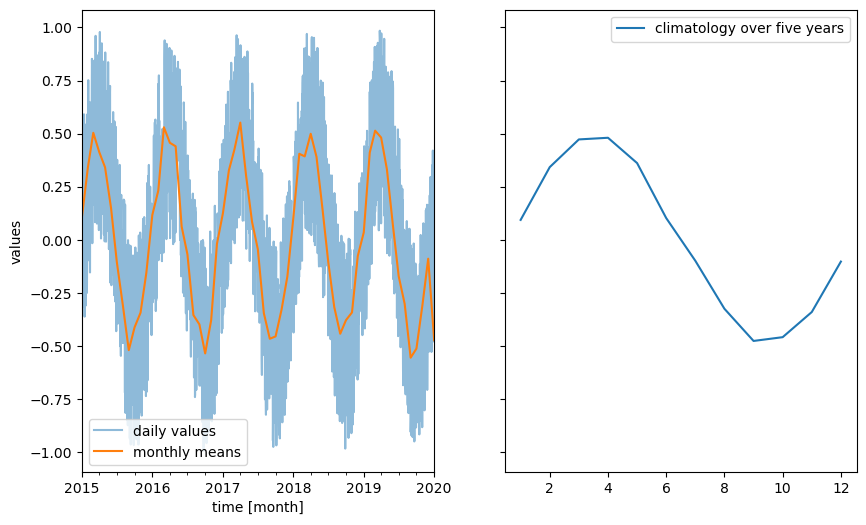

In [9]:
# 3. Create a a daily time series from 2015-2020 with an noisy annual cycle.
# Resample the data by taking the mean over each month using `resample('M')`.
# Create the climatology (monhtly means) using the groupby(timeseries.index.month) operator.

dates = pd.date_range(start='2015-01-01', end='2020-01-01', freq='D')
timeseries = pd.Series(.5*np.sin(2*np.pi*dates.dayofyear/365)+np.random.rand((len(dates)))-.5,
                       index=dates)
fig, ax = plt.subplots(1, 2, figsize=(10,6), sharey=True)

timeseries.plot(ax=ax[0], label='daily values', alpha=.5)
timeseries.resample('M').mean().plot(ax=ax[0], label='monthly means')
ax[0].legend()
ax[0].set_xlabel('time [years C.E.]')
ax[0].set_ylabel('values')

timeseries.groupby(timeseries.index.month).mean().plot(ax=ax[1], label='climatology over five years')
ax[1].legend()
ax[0].set_xlabel('time [month]')
plt.savefig('3a3')